In [1]:
# Importing all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# To upload any files
from google.colab import files
uploaded = files.upload()

Saving student_data.csv to student_data.csv


In [3]:
# To load csv
df=pd.read_csv('student_data.csv')

In [4]:
# Verifying the data uploaded
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
# converting g3 to pass(1) and fail(0)
df['pass']=(df['G3']>=10).astype(int)
#df['G3']>=10 this gives values in form of true or false so astype is used to convert it to integer

In [6]:
# selecting all the neccesary columns
df = df[['sex', 'age','famsize','Medu','Fedu','famrel','goout','health','absences','pass','Dalc','Walc','freetime','traveltime','studytime','failures','romantic']]

In [7]:
# df['column'] = df['column'].map({'value1': 0, 'value2': 1})
df['sex'] = df['sex'].map({'F': 0, 'M': 1})
df['famsize'] = df['famsize'].map({'LE3': 0, 'GT3': 1})
df['romantic'] = df['romantic'].map({'no': 0, 'yes': 1})

In [8]:
# (Head shows first five rows) Verifying that the desired columns are selected and no string value
df.head()

,sex,age,famsize,Medu,Fedu,famrel,goout,health,absences,pass,Dalc,Walc,freetime,traveltime,studytime,failures,romantic
0,0,18,1,4,4,4,4,3,6,0,1,1,3,2,2,0,0
1,0,17,1,1,1,5,3,3,4,0,1,1,3,1,2,0,0
2,0,15,0,1,1,4,2,3,10,1,2,3,3,1,2,3,0
3,0,15,1,4,2,3,2,5,2,1,1,1,2,1,3,0,1
4,0,16,1,3,3,4,2,5,4,1,1,2,3,1,2,0,0


In [9]:
# Selecting features for X and y
X=df.drop('pass',axis=1)
y=df['pass']
X.head()

,sex,age,famsize,Medu,Fedu,famrel,goout,health,absences,Dalc,Walc,freetime,traveltime,studytime,failures,romantic
0,0,18,1,4,4,4,4,3,6,1,1,3,2,2,0,0
1,0,17,1,1,1,5,3,3,4,1,1,3,1,2,0,0
2,0,15,0,1,1,4,2,3,10,2,3,3,1,2,3,0
3,0,15,1,4,2,3,2,5,2,1,1,2,1,3,0,1
4,0,16,1,3,3,4,2,5,4,1,2,3,1,2,0,0


In [10]:
#spliting the data
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [11]:
# using random forest whiich will help in making in unbiased decisions
model=RandomForestClassifier(random_state=42, n_estimators=400)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=400, random_state=42)

In [12]:
# testing the model's accuracy
y_pred=model.predict(X_test)

In [13]:
# prinitng accuarcy
print(accuracy_score(y_test, y_pred))

0.6962025316455697


In [14]:
# printing classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.35      0.43        26
           1       0.73      0.87      0.79        53

    accuracy                           0.70        79
   macro avg       0.65      0.61      0.61        79
weighted avg       0.67      0.70      0.67        79



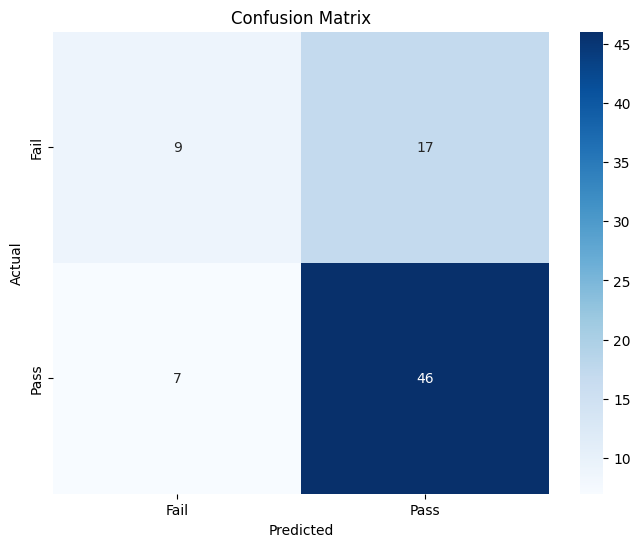

In [15]:
# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

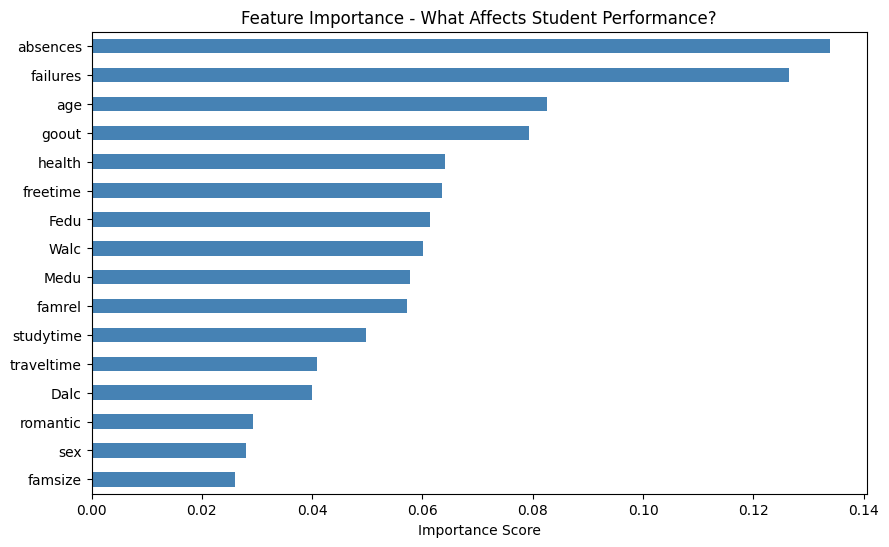

In [16]:
# Feature Importance
plt.figure(figsize=(10,6))
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance - What Affects Student Performance?')
plt.xlabel('Importance Score')
plt.show()

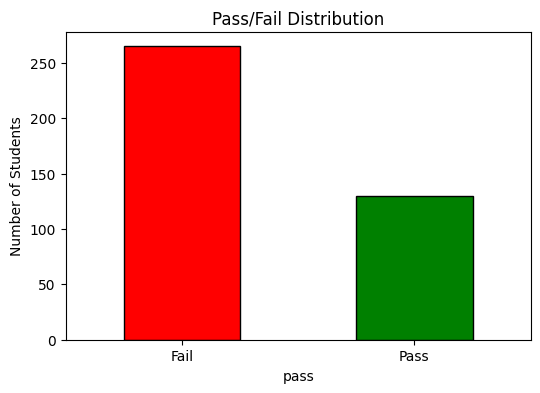

In [17]:
# Pass/Fail Distribution
plt.figure(figsize=(6,4))
df['pass'].value_counts().plot(kind='bar',
                                color=['red','green'],
                                edgecolor='black')
plt.title('Pass/Fail Distribution')
plt.xticks([0,1], ['Fail','Pass'], rotation=0)
plt.ylabel('Number of Students')
plt.show()